# Exercise

https://www.kaggle.com/code/anuya09/titanic-machine-learning-from-disaster

### 1. Import libraries

In [236]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

### 2. Read data

In [208]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [209]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 3. Checking Dimensions of Data

In [125]:
print("Training Dataset shape is: ", train_df.shape)
print("Testing Dataset shape is: ", test_df.shape)

Training Dataset shape is:  (891, 12)
Testing Dataset shape is:  (418, 11)


In [126]:
test_df[:3]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q


### 4. Checking Duplicates Data

In [127]:
print(
    f"Duplicates in Train Dataset is: {train_df.duplicated().sum()} ({100 * train_df.duplicated().sum() / len(train_df)}%)")
print(
    f"Duplicates in Test Dataset is: {test_df.duplicated().sum()} ({100 * test_df.duplicated().sum() / len(test_df)}%)")

Duplicates in Train Dataset is: 0 (0.0%)
Duplicates in Test Dataset is: 0 (0.0%)


### 5. Checking Data types

In [128]:
print("Data Types of Training Data is: \n")
print(train_df.dtypes)

Data Types of Training Data is: 

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


In [129]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


### 6.a Checking Total Number & Percentage of Missing Values in Training Dataset

In [130]:
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [210]:
df_missing = (train_df.isnull().sum()[train_df.isnull().sum() > 0]).to_frame().rename(
    columns={0: "Number of Missing values"})
df_missing["% of Missing Values"] = round((100 * train_df.isnull().sum()[train_df.isnull().sum() > 0] / len(train_df)),
                                          2)
df_missing

,Number of Missing values,% of Missing Values
Age,177,19.87
Cabin,687,77.10
Embarked,2,0.22


### 6.b Checking Total Number & Percentage of Missing Values in Test Dataset

In [132]:
test_df.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [211]:
df_missing = (test_df.isnull().sum()[test_df.isnull().sum() > 0]).to_frame().rename(
    columns={0: "Number of Missing values"})
df_missing["% of Missing Values"] = round((100 * test_df.isnull().sum()[test_df.isnull().sum() > 0] / len(test_df)), 2)
df_missing

,Number of Missing values,% of Missing Values
Age,86,20.57
Fare,1,0.24
Cabin,327,78.23


### 7. Visualizing (missing and existing) numbers

In [134]:
train_df.notna().sum()

PassengerId    891
Survived       891
Pclass         891
Name           891
Sex            891
Age            714
SibSp          891
Parch          891
Ticket         891
Fare           891
Cabin          204
Embarked       889
dtype: int64

Text(0.5, 1.0, 'Training Dataset vs. Test Dataset (nr of values)')

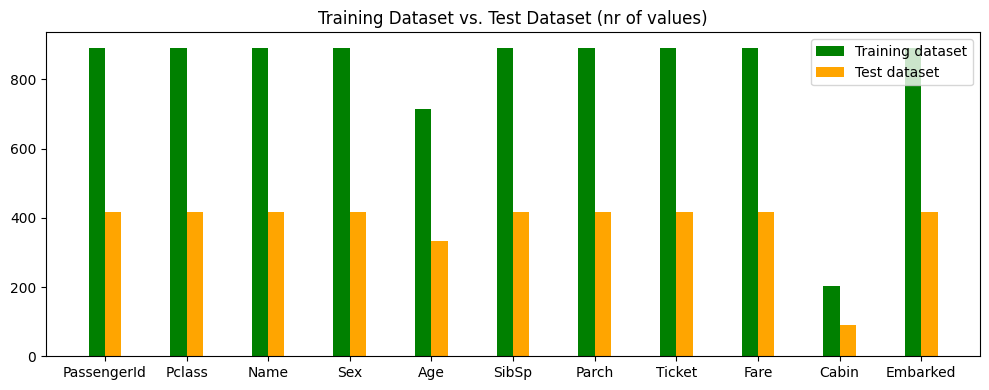

In [135]:
chart_x = train_df.drop('Survived', axis=1).notna().sum().index
chart_y1 = train_df.drop('Survived', axis=1).notna().sum()
chart_y2 = test_df.notna().sum()

width = 0.2
x = np.arange(len(chart_x))

plt.figure(figsize=(10, 4), tight_layout=True)
plt.bar(x - width / 2, chart_y1, width, color="green")
plt.bar(x + width / 2, chart_y2, width, color="orange")
plt.xticks(x, chart_x)
plt.legend(["Training dataset", "Test dataset"])
plt.title("Training Dataset vs. Test Dataset (nr of values)")

### 8. Handling missing values

In [212]:
# drop unwanted columns
train_df = train_df.drop(['Cabin', 'Name', 'Ticket', 'Fare', 'PassengerId'], axis=1)
test_df = test_df.drop(['Cabin', 'Name', 'Ticket', 'Fare', 'PassengerId'], axis=1)

In [213]:
# train_df
mean_imputer = SimpleImputer(strategy='mean')
train_df['Age'] = mean_imputer.fit_transform(train_df[['Age']])

train_df[5:8]

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
5,0,3,male,29.699118,0,0,Q
6,0,1,male,54.000000,0,0,S
7,0,3,male,2.000000,3,1,S


In [214]:
# test_df
mean_imputer = SimpleImputer(strategy='mean')
test_df['Age'] = mean_imputer.fit_transform(test_df[['Age']])

test_df[:3]

,Pclass,Sex,Age,SibSp,Parch,Embarked
0,3,male,34.5,0,0,Q
1,3,female,47.0,1,0,S
2,2,male,62.0,0,0,Q


In [215]:
mean_imputer = SimpleImputer(strategy='most_frequent')
train_df.iloc[:, :] = mean_imputer.fit_transform(train_df)
test_df.iloc[:, :] = mean_imputer.fit_transform(test_df)

# no more null value left

In [216]:
train_df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Embarked    0
dtype: int64

### 9. Categorical and numerical columns

In [217]:
cat_cols = train_df.select_dtypes(include=["object", "str", "bool"]).columns.tolist()
num_cols = train_df.select_dtypes(include=["int", "float"]).columns.tolist()

In [218]:
print("Categorical Columns:", cat_cols)
print("-" * 120)
print("Numerical Columns:", num_cols)

Categorical Columns: ['Sex', 'Embarked']
------------------------------------------------------------------------------------------------------------------------
Numerical Columns: ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch']


In [219]:
train_df[:3]

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,0,3,male,22.0,1,0,S
1,1,1,female,38.0,1,0,C
2,1,3,female,26.0,0,0,S


### 10. Checking Cardinality of Categorical Features

In [220]:
print("Cardinality of features in numerical data is: ")
print(train_df.select_dtypes(include=["int", "float"]).nunique())
print("-" * 50)

print("Cardinality of features in categorical data is: ")
print(test_df.select_dtypes(include=["object", "str", "bool"]).nunique())

Cardinality of features in numerical data is: 
Survived     2
Pclass       3
Age         89
SibSp        7
Parch        7
dtype: int64
--------------------------------------------------
Cardinality of features in categorical data is: 
Sex         2
Embarked    3
dtype: int64


### 11. Handle categorical variables

- drop
- dummy
- ordinal encoding
- one-hot encoding
- label encoding

In [221]:
train_df[:3]

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,0,3,male,22.0,1,0,S
1,1,1,female,38.0,1,0,C
2,1,3,female,26.0,0,0,S


In [222]:
label_encoder = LabelEncoder()
ordinal_cat_cols = ["Pclass", "SibSp", "Parch"]

train_df[ordinal_cat_cols] = train_df[ordinal_cat_cols].apply(label_encoder.fit_transform)
test_df[ordinal_cat_cols] = test_df[ordinal_cat_cols].apply(label_encoder.fit_transform)

In [223]:
nominal_cat_cols = ["Sex", "Embarked"]

train_df = pd.get_dummies(train_df, columns=nominal_cat_cols)
test_df = pd.get_dummies(test_df, columns=nominal_cat_cols)

In [224]:
train_df[:5]

,Survived,Pclass,Age,SibSp,Parch,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,2,22.0,1,0,False,True,False,False,True
1,1,0,38.0,1,0,True,False,True,False,False
2,1,2,26.0,0,0,True,False,False,False,True
3,1,0,35.0,1,0,True,False,False,False,True
4,0,2,35.0,0,0,False,True,False,False,True


In [225]:
test_df[:5]

,Pclass,Age,SibSp,Parch,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,2,34.5,0,0,False,True,False,True,False
1,2,47.0,1,0,True,False,False,False,True
2,1,62.0,0,0,False,True,False,True,False
3,2,27.0,0,0,False,True,False,False,True
4,2,22.0,1,1,True,False,False,False,True


### 12. Selecting Features & Labels For Model Training

In [226]:
X = train_df.drop(columns=["Survived"])
y = train_df["Survived"]

### 13. Feature Scaling

In [227]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
test_df_scaled = scaler.fit_transform(test_df)

### 14. Model training

In [229]:
# Splitting data for model which doesn't need scaled data

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [232]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(712, 9) (712,)
(179, 9) (179,)


In [233]:
# Splitting data for model which needs scaled data

x_train_scaled, x_test_scaled, y_train_scaled, y_test_scaled = (
    train_test_split(X_scaled, y, test_size=0.2, random_state=1))

In [234]:
print(x_train_scaled.shape, y_train_scaled.shape)
print(x_test_scaled.shape, y_test_scaled.shape)

(712, 9) (712,)
(179, 9) (179,)


In [239]:
training_score = []
testing_score = []


def model_prediction(model):
    model.fit(x_train_scaled, y_train_scaled)
    x_train_predicted = model.predict(x_train_scaled)
    x_test_predicted = model.predict(x_test_scaled)
    a = accuracy_score(y_train_scaled, x_train_predicted) * 100
    b = accuracy_score(y_test_scaled, x_test_predicted) * 100
    training_score.append(a)
    testing_score.append(b)

    print(f"Accuracy_Score of {model} model on Training Data is:", a)
    print(f"Accuracy_Score of {model} model on Testing Data is:", b)
    print("------------------------------------------------------------------------")
    print(f"Precision Score of {model} model is:", precision_score(y_test_scaled, x_test_predicted))
    print(f"Recall Score of {model} model is:", recall_score(y_test_scaled, x_test_predicted))
    print(f"F1 Score of {model} model is:", f1_score(y_test_scaled, x_test_predicted))
    print("------------------------------------------------------------------------")


### 15. Model evaluation

**Logistic-Regression Model**

In [241]:
from sklearn.linear_model import LogisticRegression

model_prediction(LogisticRegression())

Accuracy_Score of LogisticRegression() model on Training Data is: 79.63483146067416
Accuracy_Score of LogisticRegression() model on Testing Data is: 79.88826815642457
------------------------------------------------------------------------
Precision Score of LogisticRegression() model is: 0.7605633802816901
Recall Score of LogisticRegression() model is: 0.7397260273972602
F1 Score of LogisticRegression() model is: 0.75
------------------------------------------------------------------------
